## 01. 분류 평가지표  

분류 평가지표는 모델이 예측한 class와 실제 class를 비교해 분류 모델의 성능을 수치로 표현한 기준이다.  
분류 모델은 각 데이터를 여러 class 중 하나로 예측하므로, 평가지표는 모델이 class를 얼마나 잘 구분했는지 확인하는 데 사용한다.  

분류 평가는 단순히 전체 정답률만 보는 것이 아니라, 어떤 class를 잘 맞히는지, 어떤 class를 자주 놓치는지, 어떤 class로 잘못 예측하는지도 함께 확인해야 한다.  
그래서 분류 문제에서는 `accuracy`, `precision`, `recall`, `f1-score`, `ROC-AUC` 같은 지표를 상황에 맞게 함께 사용한다.  

- `accuracy`: 전체 데이터 중 예측이 실제 정답과 일치한 비율임.  
- `precision`: 모델이 특정 class라고 예측한 데이터 중 실제로 그 class가 맞은 비율임.  
- `recall`: 실제 특정 class 데이터 중 모델이 그 class로 찾아낸 비율임.  
- `f1-score`: precision과 recall의 균형을 함께 보는 지표임.  
- `ROC-AUC`: class를 구분하는 확률 점수의 전반적인 분리 능력을 보는 지표임.  

**분류 모델과 평가의 관계**  

- 분류 모델: class를 예측하는 모델임.  
- 분류 평가지표: 모델의 class 예측 결과가 실제 정답과 얼마나 잘 맞는지 판단하는 기준임.  

정확도는 전체 중 몇 개를 맞혔는지 보는 가장 쉬운 지표이다.  
하지만 데이터가 불균형하거나, 어떤 실수가 더 치명적인 문제에서는 정확도만으로 모델을 판단하기 어렵다.  

**배우는 이유**  
- 모델이 맞힌 개수만 보는 것이 아니라 어떤 오류를 냈는지 확인하기 위해 사용함.  
- 실제 서비스에서는 FP와 FN의 비용이 다를 수 있음.  
- 여러 모델 중 어떤 모델을 선택할지 근거를 만들기 위해 사용함.  

**어디서 사용하는가?**  
- 스팸 필터: 정상 메일을 스팸으로 보내는 FP가 문제될 수 있음.  
- 질병 진단: 실제 환자를 정상으로 예측하는 FN이 치명적일 수 있음.  
- 사기 탐지: 사기 거래를 놓치는 FN과 정상 거래를 막는 FP를 함께 봐야 함.  
- 이탈 예측: 이탈할 고객을 놓치지 않는 Recall이 중요할 수 있음.  

**핵심 용어**  
- Positive: 관심 있는 class.  
ex) Titanic 생존자 `Survived=1`을 Positive로 둠.  
- Negative: 관심 class가 아닌 경우.  
ex) Titanic에서는 사망 `Survived=0`을 Negative로 둠.  
- Threshold: 확률을 class로 바꿀 때 사용하는 기준값. 기본적으로 0.5를 많이 사용함.  


## 02. 실습 환경 준비

Titanic 데이터로 이진분류 평가를 실습하고, Wine 데이터로 다중분류 평가를 확인한다.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)


## 03. Titanic 데이터 로드

`Survived=1`을 생존, `Survived=0`을 사망으로 두고 평가 지표를 해석한다.


In [2]:

titanic_df = pd.read_csv('data/titanic_train.csv')

print('shape:', titanic_df.shape)
print('target distribution:')
print(titanic_df['Survived'].value_counts(normalize=True).round(3))
display(titanic_df.head())


shape: (891, 12)
target distribution:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 04. Feature/Target 분리와 학습/평가 데이터 분리

모델이 사용할 feature와 맞혀야 할 target을 분리.


In [3]:
titanic_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

titanic_X = titanic_df[titanic_features]
titanic_y = titanic_df['Survived']

titanic_X_train, titanic_X_test, titanic_y_train, titanic_y_test = train_test_split(
    titanic_X,
    titanic_y,
    test_size=0.2,
    random_state=42,
    stratify=titanic_y,
)

print('train:', titanic_X_train.shape, titanic_y_train.shape)
print('test:', titanic_X_test.shape, titanic_y_test.shape)
print('train target ratio:')
print(titanic_y_train.value_counts(normalize=True).round(3))
print('test target ratio:')
print(titanic_y_test.value_counts(normalize=True).round(3))


train: (712, 7) (712,)
test: (179, 7) (179,)
train target ratio:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64
test target ratio:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 05. 전처리 Pipeline 구성

Titanic 데이터에는 숫자 feature와 문자 범주형 feature가 함께 있다.
숫자 feature는 결측치를 중앙값으로 채우고 스케일링하며, 범주형 feature는 결측치를 최빈값으로 채우고 One-Hot Encoding한다.


In [5]:
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

categorical_features = ['Sex', 'Embarked']

def make_titanic_preprocessor():

    # imputer : 불순물 == 결측치
    # SimpleImputer(strategy = 'median'
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    # SimpleImputer(strategy='most_frequent') : 범주형 결측치를 최빈값으로 처리
    # OneHotEncoder(handle_unknown='ignore') : 학습되지 않은 범주형 데이터가 입력되면 오류를 무시해라
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    # ColumnTrangformer() : 컬럼 그룹별로 서로 다른 전처리를 적용하는 객체
    return ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

titanic_preprocessor = make_titanic_preprocessor()
print(titanic_preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked'])])


## 06. 비교할 모델 만들기

평가지표는 모델 하나만 볼 때보다 여러 모델을 비교할 때 더 의미가 분명해진다.
기준 모델, 로지스틱 회귀, 랜덤 포레스트를 같은 test 데이터에서 비교한다.


In [8]:
# 기준 모델 - DummyClassifier(strategy='most_frequent')
# - 가장 많은 class만 예측하는 기준점 전용 모델
dummy_model = DummyClassifier(strategy='most_frequent')
# LogisticRegression()
logistic_model = Pipeline([
    ('preprocessor', make_titanic_preprocessor()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# RandomForestClassifier()
random_forest_model = Pipeline([
    ('preprocessor', make_titanic_preprocessor()),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

classification_models = {
    'dummy_most_frequent': dummy_model,
    'logistic_regression': logistic_model,
    'random_forest': random_forest_model,
}

### 07. Accuracy의 한계 확인

Accuracy는 전체 예측 중 맞힌 비율이다.
직관적이지만 class 비율이 한쪽으로 치우친 데이터에서는 모델이 소수 class를 거의 못 맞혀도 높게 보일 수 있다.


In [17]:
metric_rows = []

for model_name, model in classification_models.items():

    model.fit(titanic_X_train, titanic_y_train) # 학습

    y_pred = model.predict(titanic_X_test) # 예측

    # predict_proba(): class별 예측 확률 반환
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(titanic_X_test)[:, 1]
    else:
        y_score = y_pred

    metric_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(titanic_y_test, y_pred),
        'precision': precision_score(titanic_y_test, y_pred, zero_division=0),
        'recall': recall_score(titanic_y_test, y_pred, zero_division=0),
        'f1_score': f1_score(titanic_y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(titanic_y_test, y_score),
    })

    # accuracy (정확도): 전체 승객 중 생존/사망 여부를 맞게 예측한 비율 (가장 직관적인 지표)
    # precision (정밀도): 모델이 '생존'이라고 예측한 사람들 중 '실제 생존자'의 비율 (과탐지 줄이기)
    # recall (재현율): '실제 생존자'들 중 모델이 생존했다고 올바르게 맞춘 비율 (미탐지 줄이기)
    # f1_score (F1 스코어): 정밀도와 재현율의 조화평균 (두 지표가 균형을 이루는지 판단하는 지표)
    # roc_auc (ROC-AUC 점수): 모델이 생존자와 사망자를 얼마나 잘 구별(분류)하는지 나타내는 종합적 성능 지표

classification_metrics_df \
    = pd.DataFrame(metric_rows).sort_values('f1_score', ascending=False)

display(classification_metrics_df)

,model,accuracy,precision,recall,f1_score,roc_auc
2,random_forest,0.815642,0.800000,0.695652,0.744186,0.830040
1,logistic_regression,0.804469,0.793103,0.666667,0.724409,0.843742
0,dummy_most_frequent,0.614525,0.000000,0.000000,0.000000,0.500000


## 08. Confusion Matrix(혼동행렬) 해석

Confusion Matrix는 실제값과 예측값의 조합을 표로 정리한다.
이진분류에서는 `TN`, `FP`, `FN`, `TP` 네 가지 경우를 확인한다.

- TN: 실제 0을 0으로 맞힌 경우
- FP: 실제 0인데 1로 잘못 예측한 경우
- FN: 실제 1인데 0으로 잘못 예측한 경우
- TP: 실제 1을 1로 맞힌 경우


In [18]:
# 로지스틱 모델을 선택해서 평가 진행 -> 혼동 행렬 생성
selected_model = logistic_model

selected_pred = selected_model.predict(titanic_X_test)
selected_proba = selected_model.predict_proba(titanic_X_test)[:,1]

# 혼동 행렬(confusion matrix) 생성
# - 실제값과 예측값을 이요해서 조합별 개수를 계산한 행렬 생성
cm = confusion_matrix(titanic_y_test, selected_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index = [ 'actual_0_dead','actual_1_survived'],
    columns = [ 'pred_0_dead','pred_1_survived']
)

display(cm_df)

# cm.ravel(): 2 X 2 혼동행렬을 tn, fp, fn, tp 순서로 반환
tn, fp, fn, tp = cm.ravel()
print('TN:', tn)
print('FP:', fp)
print('FN:', fn)
print('TP:', tp)

,pred_0_dead,pred_1_survived
actual_0_dead,98,12
actual_1_survived,23,46


TN: 98
FP: 12
FN: 23
TP: 46


## 09. Precision, Recall, F1-score

Precision은 모델이 Positive라고 예측한 것 중 실제 Positive 비율이다.
Recall은 실제 Positive 중 모델이 찾아낸 비율이다.
F1-score는 Precision과 Recall의 균형을 보는 지표이다.


In [20]:
precision = precision_score(titanic_y_test, selected_pred, zero_division=0)
recall = recall_score(titanic_y_test, selected_pred, zero_division=0)
f1 = f1_score(titanic_y_test, selected_pred, zero_division=0)

print('precision:', round(precision, 4))
print('recall:', round(recall, 4))
print('f1_score:', round(f1, 4))


# classification_report(): class별 precision, recall, f1-score, support를 한 번에 출력
print(classification_report(
    titanic_y_test,
    selected_pred,
    target_names=['dead', 'survived'],
    zero_division=0,
))

precision: 0.7931
recall: 0.6667
f1_score: 0.7244
              precision    recall  f1-score   support

        dead       0.81      0.89      0.85       110
    survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 10. Threshold 변화와 Precision/Recall Trade-off

로지스틱 회귀는 먼저 생존 확률을 계산한다.
기본 threshold 0.5를 기준으로 확률이 0.5 이상이면 생존으로 예측한다.

threshold를 낮추면 Positive 예측이 늘어나 Recall이 올라갈 수 있지만 FP도 늘 수 있다.
threshold를 높이면 Positive 예측이 줄어 Precision이 올라갈 수 있지만 FN도 늘 수 있다.


In [22]:
threshold_rows = []
print(selected_proba)
for threshold in [0.3, 0.5, 0.7]:
    # 확률이 threshold 이상이면 Positive class인 생존(1)로 예측한다.
    threshold_pred = (selected_proba >= threshold).astype(int)

    threshold_rows.append({
        'threshold': threshold,
        'positive_predictions': int(threshold_pred.sum()),
        'accuracy': accuracy_score(titanic_y_test, threshold_pred),
        'precision': precision_score(titanic_y_test, threshold_pred, zero_division=0),
        'recall': recall_score(titanic_y_test, threshold_pred, zero_division=0),
        'f1_score': f1_score(titanic_y_test, threshold_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))

[0.06797269 0.04764082 0.15524286 0.03571093 0.67237813 0.44277982
 0.75280449 0.32759601 0.34702495 0.16138012 0.15822152 0.08931277
 0.58512847 0.23185151 0.47072732 0.17706904 0.37886933 0.08834728
 0.13105439 0.76689954 0.08834728 0.77710621 0.08379023 0.43422947
 0.08677497 0.96053681 0.15822152 0.26353134 0.12313529 0.12674477
 0.07266537 0.9480917  0.09504131 0.09978522 0.1313043  0.15364727
 0.15274057 0.36871013 0.15822152 0.8389387  0.12817445 0.96828335
 0.12237837 0.86322987 0.76295677 0.11460743 0.08859141 0.40108302
 0.76871819 0.8815446  0.92342448 0.57106025 0.72079107 0.22849835
 0.72193186 0.09644115 0.07155546 0.41743191 0.63993207 0.42698906
 0.60927085 0.70178966 0.13567566 0.13404055 0.41082825 0.55498833
 0.94263794 0.07552292 0.20996901 0.26057654 0.74406634 0.12508267
 0.68783669 0.95877155 0.19906327 0.05008289 0.07010486 0.07978928
 0.15304373 0.5460467  0.07053737 0.11887786 0.14577924 0.09639112
 0.7752797  0.28266548 0.10672695 0.51427717 0.56302088 0.9511

,threshold,positive_predictions,accuracy,precision,recall,f1_score
0,0.3,84,0.7598,0.6548,0.7971,0.7190
1,0.5,58,0.8045,0.7931,0.6667,0.7244
2,0.7,39,0.7877,0.8974,0.5072,0.6481


## 11. ROC Curve와 ROC-AUC
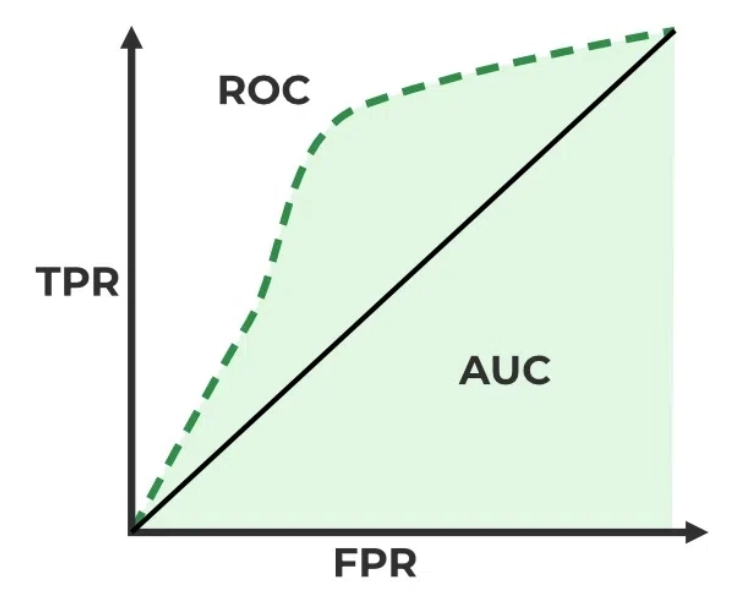

- TPR(True Positive Rate): 실제 Positive 중 모델이 Positive로 맞힌 비율이다. Recall과 같은 의미이다.
- FPR(False Positive Rate): 실제 Negative 중 모델이 Positive로 잘못 예측한 비율이다.
- ROC Curve는 threshold를 바꾸면서 TPR은 얼마나 높아지고, FPR은 얼마나 함께 늘어나는지 보는 그래프이다.


ROC Curve는 threshold를 계속 바꿨을 때 TPR과 FPR이 어떻게 변하는지 보여준다.
ROC-AUC는 ROC Curve 아래 면적으로,
1에 가까울수록 positive와 negative를 잘 구분한다는 뜻이다.


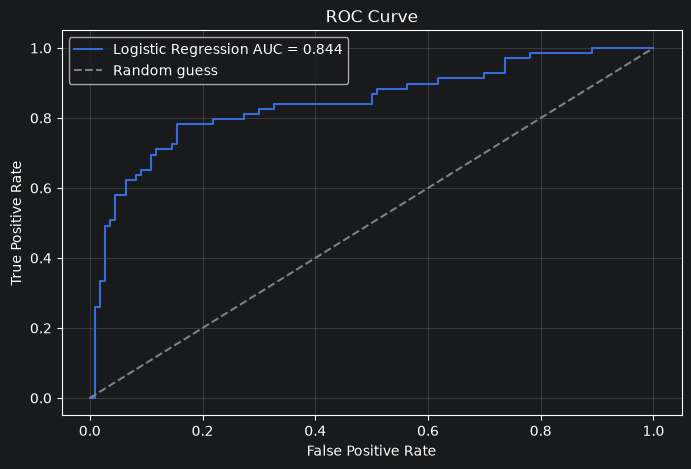

ROC-AUC: 0.8437


In [24]:
# roc_curve(): thresholds 변화에 따른 FPR, TPR 값을 계산하는 함수
fpr, tpr, roc_thresholds = roc_curve(titanic_y_test, selected_proba)

# roc_auc_score(): 확률 점수 기준으로 P/N를 얼마나 잘 구분하는지 계산하는 함수
# == 그래프의 초록색 면적 부분 == 1에 가까울수록 P/N을 잘 구분한다!
auc_score = roc_auc_score(titanic_y_test, selected_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('ROC-AUC:', round(auc_score, 4))

# 점선 : 무작위 예측 수준을 의미

# 점선 위쪽으로 곡선 (ROC Curve)이 형성
# == 모델이 무작위로 예측하는 것보단 생존/사망 잘 구분한다
# - 곡선이 왼쪽 위로 올라갈수록 더 구분을 잘 한다고 해석


# ROC-AUC 가 현재 0.844로 생존/사망 구분을 잘한다고 판단.
# 단, ROC-AUC 노아도 threshold에서 precision, recall이 원하는 수준인지는
# 별도로 판단해야한다.
# ex) 생존자 예측이 중요하다(생존자를 놓치지 않는것이 중요하다)
#     -> ROC-AUC만 가지고는 생존자 예측 정도를 확인하는 것이 어렵다.
#     -> recall, threshold 조정 결과도 확인할 필요가 있다.

## 12. 다중분류 평가: Wine 데이터

다중분류에서는 class가 3개 이상이다.
이 경우 class별 precision, recall, f1-score를 확인하고,
macro average와 weighted average를 함께 본다.

- macro avg: class별 점수를 단순 평균함. 소수 class도 같은 비중으로 봄.
- weighted avg: class별 support를 반영해 평균함. 샘플 수가 많은 class의 영향이 더 큼.


In [25]:
wine = load_wine(as_frame=True)
wine_X = wine.data
wine_y = wine.target

wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X,
    wine_y,
    test_size=0.2,
    random_state=42,
    stratify=wine_y,
)

wine_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

wine_model.fit(wine_X_train, wine_y_train)
wine_pred = wine_model.predict(wine_X_test)

print('accuracy:', round(accuracy_score(wine_y_test, wine_pred), 4))
print('macro f1:', round(f1_score(wine_y_test, wine_pred, average='macro'), 4))
print('weighted f1:', round(f1_score(wine_y_test, wine_pred, average='weighted'), 4))
print()
print(classification_report(
    wine_y_test,
    wine_pred,
    target_names=wine.target_names,
    zero_division=0,
))

# macro f1 : 모든 클래스를 같은 비중으로
# weighted f1 : 클래스 별 샘플 수 (support)를 반영해서 평균 계산
#               == 가중치를 다르게 주고 계산
# class의 불균형이 심할 경우

accuracy: 0.9722
macro f1: 0.971
weighted f1: 0.972

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## 13. 다중분류 Confusion Matrix 시각화

다중분류 confusion matrix는 어떤 class를 어떤 class로 헷갈렸는지 보여준다.
대각선 값은 맞힌 개수이고, 대각선 밖 값은 잘못 예측한 개수이다.


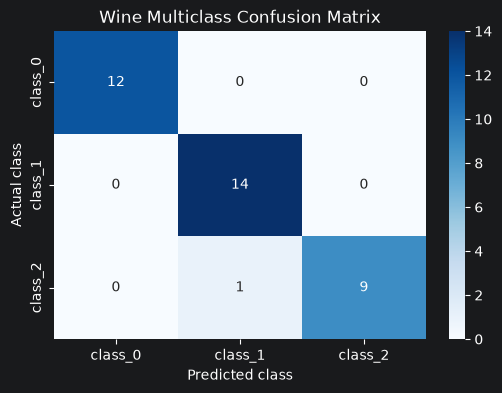

In [27]:
wine_cm = confusion_matrix(wine_y_test, wine_pred)
wine_cm_df = pd.DataFrame(
    wine_cm,
    index=wine.target_names,
    columns=wine.target_names,
)

plt.figure(figsize=(6, 4))
sns.heatmap(wine_cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Wine Multiclass Confusion Matrix')
plt.show()

# 다중 분류를 표시한 혼동 행렬에서
# - 대각선으로 값이 몰려있으면 모델이 class 예측을 잘하고 있는 것으로 판단!
# - 대각선 밖 값은 class 끼리 어떤 혼동이 발생했는지를 보여준다.
# - confusion matrix는 점수보다 오류 패턴 설명에 도움이된다.

## 14. 분류 평가지표 정리

- Accuracy: 전체 중 맞힌 비율임.
- Precision: Positive라고 예측한 것 중 실제 Positive 비율임.
- Recall: 실제 Positive 중 모델이 찾아낸 비율임.
- F1-score: Precision과 Recall의 균형 지표임.
- ROC-AUC: threshold 전반에서 positive와 negative를 구분하는 능력을 보는 지표임.
- Macro avg: class별 점수를 단순 평균함.
- Weighted avg: class별 샘플 수를 반영해 평균함.

분류 모델을 평가할 때는 “점수가 몇 점이다”에서 끝내지 않고, 어떤 실수를 줄여야 하는 문제인지 함께 해석해야 한다.
